<a href="https://colab.research.google.com/github/wagmi9/data_Analytics/blob/main/credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/content/sample_data/credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [7]:
data.dropna(inplace=True)

In [8]:
data.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

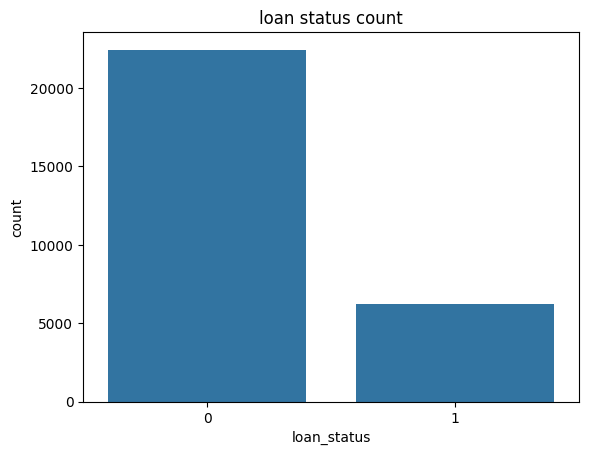

In [9]:
sns.countplot ( x='loan_status', data=data)
plt.title("loan status count")
plt.show()

ENCODING


In [11]:
data_encoded = pd.get_dummies(data,drop_first = True)

In [12]:
data_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


In [14]:
y = data_encoded['loan_status']

In [16]:
x  = data_encoded.drop('loan_status',axis=1
                       )

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train , y_test = train_test_split(x,y , test_size = 0.2)

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

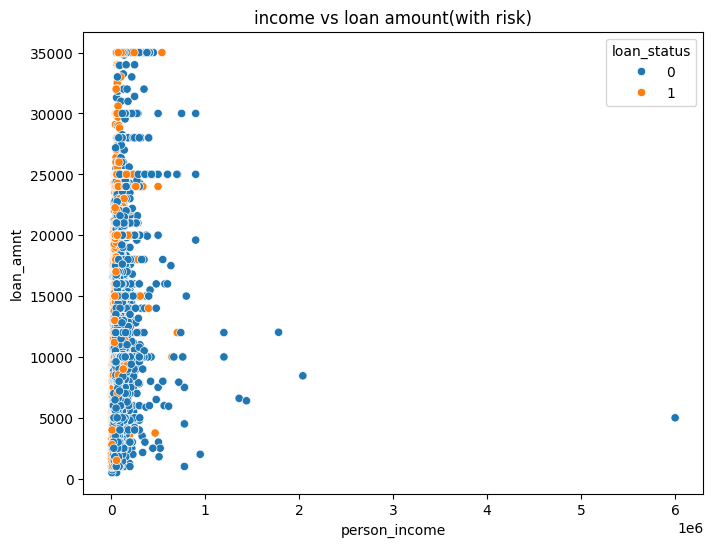

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot (x='person_income', y ='loan_amnt', hue ='loan_status', data= data)
plt.title("income vs loan amount(with risk)")
plt.show()

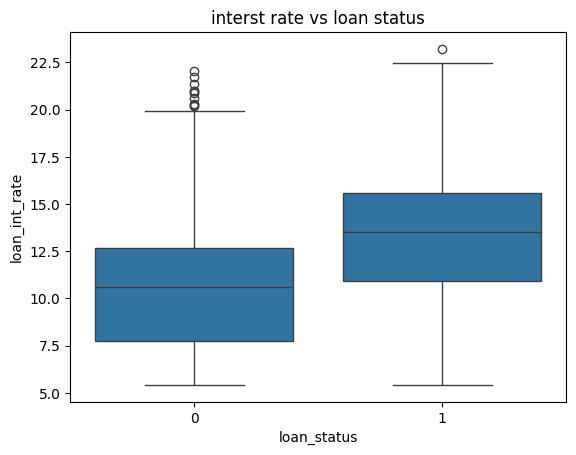

In [24]:
sns.boxplot(x='loan_status', y ='loan_int_rate', data=data)
plt.title("interst rate vs loan status")
plt.show()

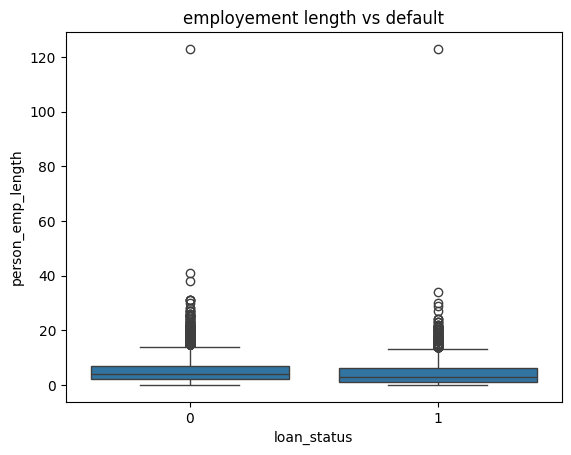

In [25]:
sns.boxplot(x='loan_status', y ='person_emp_length',data=data)
plt.title("employement length vs default")
plt.show()

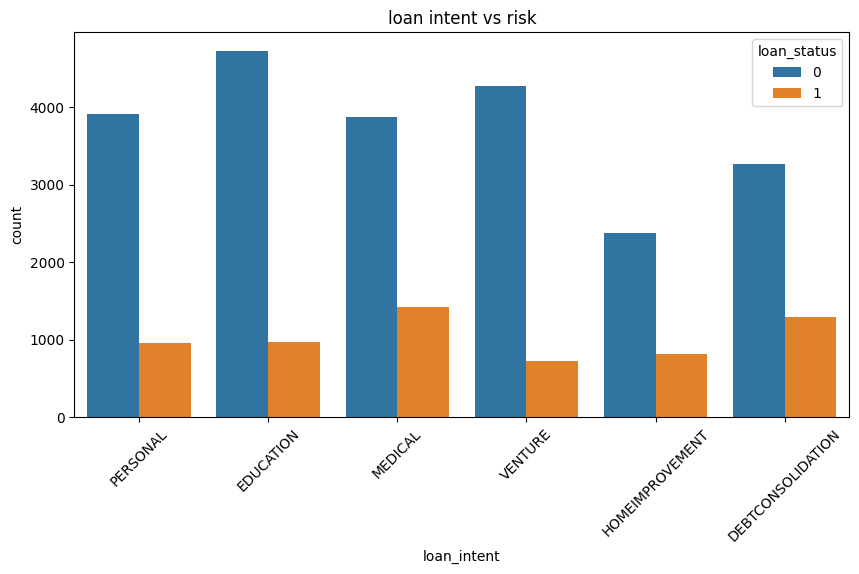

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x ='loan_intent', hue ='loan_status',data=data)
plt.xticks(rotation = 45)
plt.title("loan intent vs risk")
plt.show()

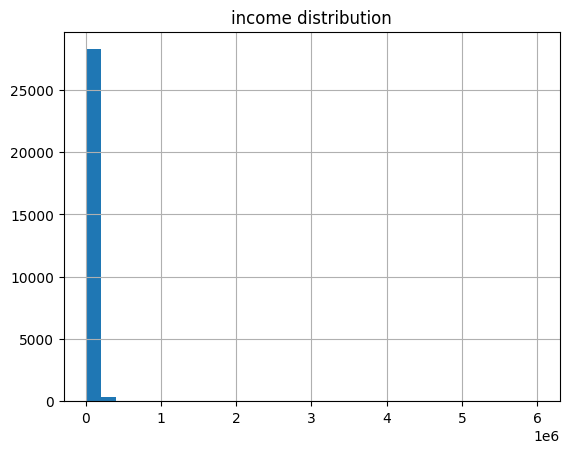

In [27]:
data['person_income'].hist(bins=30)
plt.title("income distribution")
plt.show()

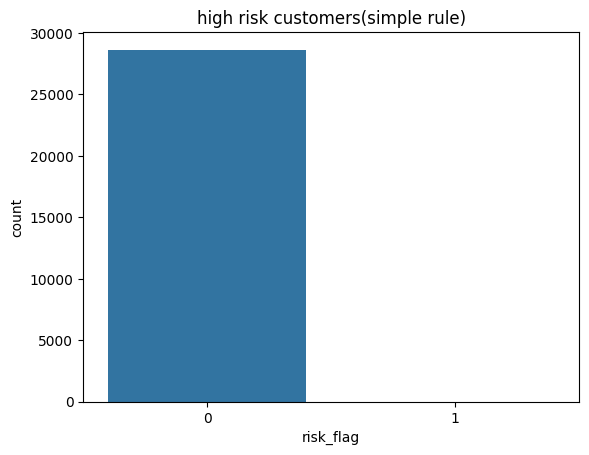

In [28]:
data['risk_flag']=((data['person_income']< 30000) & (data['loan_amnt'] > 20000)).astype(int)
sns.countplot(x='risk_flag',data=data)
plt.title("high risk customers(simple rule)")
plt.show()

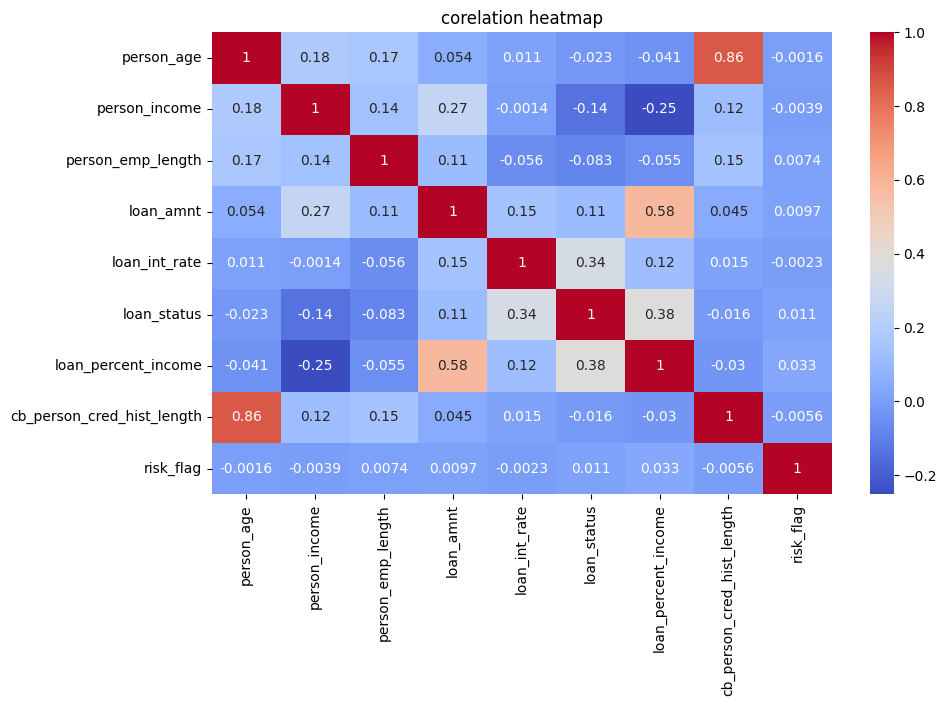

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.title("corelation heatmap")
plt.show()

In [31]:
default_rate = data['loan_status'].value_counts(normalize=True)*100
print(default_rate)

loan_status
0    78.339968
1    21.660032
Name: proportion, dtype: float64


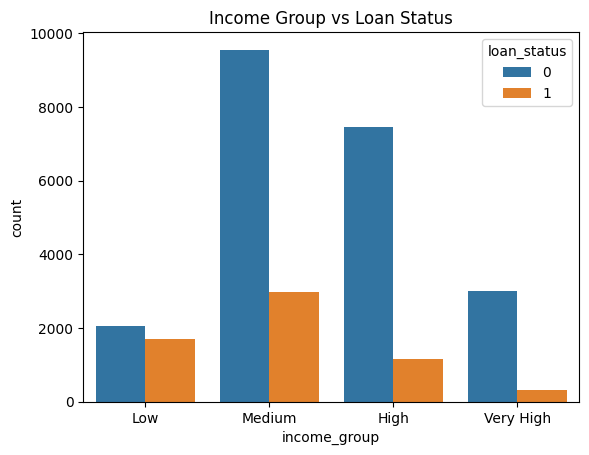

In [35]:
data['income_group'] = pd.cut(data['person_income'],
                             bins=[0,30000,60000,100000,200000],
                             labels=['Low','Medium','High','Very High'])

sns.countplot(x='income_group', hue='loan_status', data=data)
plt.title("Income Group vs Loan Status")
plt.show()

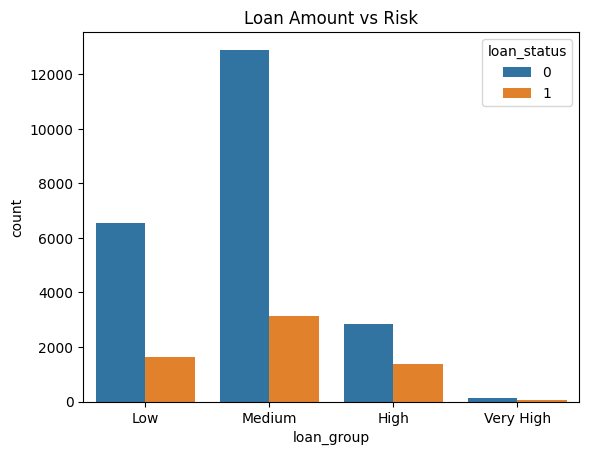

In [36]:
data['loan_group'] = pd.cut(data['loan_amnt'],
                           bins=[0,5000,15000,30000,50000],
                           labels=['Low','Medium','High','Very High'])

sns.countplot(x='loan_group', hue='loan_status', data=data)
plt.title("Loan Amount vs Risk")
plt.show()

In [37]:
data.groupby('loan_status')['person_income'].mean()

,person_income
loan_status,
0,71237.635569
1,50054.547477


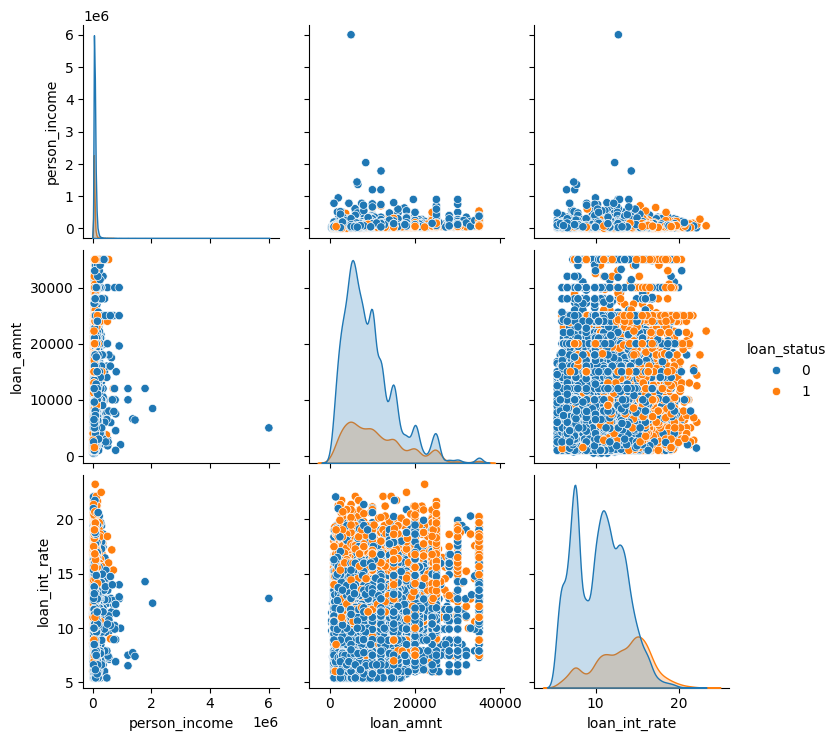

In [38]:
sns.pairplot(data[['person_income','loan_amnt','loan_int_rate','loan_status']], hue='loan_status')
plt.show()

In [39]:
data.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

,loan_status
loan_intent,
DEBTCONSOLIDATION,0.283899
MEDICAL,0.268468
HOMEIMPROVEMENT,0.256723
PERSONAL,0.197457
EDUCATION,0.170231
VENTURE,0.146171


In [40]:
data.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)

,loan_status
loan_status,1.000000
loan_percent_income,0.379689
loan_int_rate,0.339350
loan_amnt,0.113550
risk_flag,0.011238
cb_person_cred_hist_length,-0.015649
person_age,-0.023333
person_emp_length,-0.082638
person_income,-0.139938


In [42]:
X = data_encoded.drop('loan_status', axis=1)
y = data_encoded['loan_status']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[4279,  200],
       [ 637,  612]])

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      4479
           1       0.75      0.49      0.59      1249

    accuracy                           0.85      5728
   macro avg       0.81      0.72      0.75      5728
weighted avg       0.84      0.85      0.84      5728



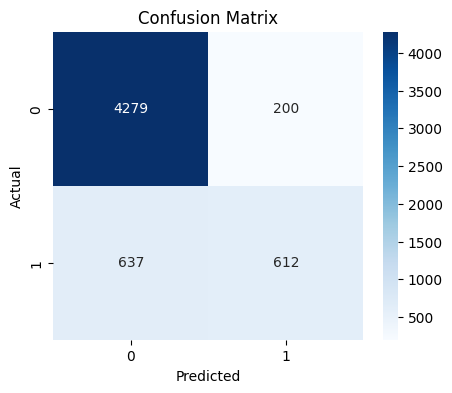

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

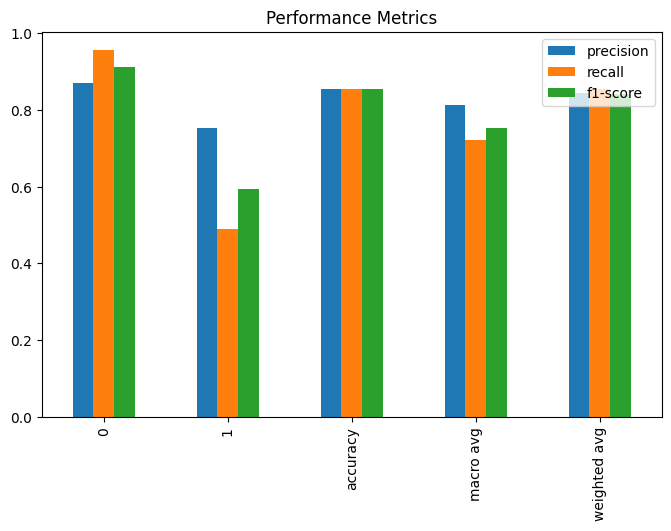

In [50]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,5))
plt.title("Performance Metrics")
plt.show()